In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('bank - bank.csv')
data.head()

,age,job,marital,education,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,deposit
0,59,admin.,married,secondary,2343,yes,no,unknown,5,may,1042,1,-1,0,yes
1,56,admin.,married,secondary,45,no,no,unknown,5,may,1467,1,-1,0,yes
2,41,technician,married,secondary,1270,yes,no,unknown,5,may,1389,1,-1,0,yes
3,55,services,married,secondary,2476,yes,no,unknown,5,may,579,1,-1,0,yes
4,54,admin.,married,tertiary,184,no,no,unknown,5,may,673,2,-1,0,yes


In [3]:
data.shape

(11162, 15)

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        11162 non-null  int64
 1   job        11162 non-null  str  
 2   marital    11162 non-null  str  
 3   education  11162 non-null  str  
 4   balance    11162 non-null  int64
 5   housing    11162 non-null  str  
 6   loan       11162 non-null  str  
 7   contact    11162 non-null  str  
 8   day        11162 non-null  int64
 9   month      11162 non-null  str  
 10  duration   11162 non-null  int64
 11  campaign   11162 non-null  int64
 12  pdays      11162 non-null  int64
 13  previous   11162 non-null  int64
 14  deposit    11162 non-null  str  
dtypes: int64(7), str(8)
memory usage: 1.3 MB


In [15]:
def check_data_type(data):
    ''' separate the data type into numerical and categorical data types
    
    :param data :the given dataset
    :return : numerical data and categorical data'''
    numerical =data.select_dtypes(['number' , 'bool'])
    categorical =data.select_dtypes(['str' ,'category','object'])

    return numerical , categorical
numerical , categorical =check_data_type(data)
display(numerical)
display(categorical)

,age,balance,day,duration,campaign,pdays,previous
0,59,2343,5,1042,1,-1,0
1,56,45,5,1467,1,-1,0
2,41,1270,5,1389,1,-1,0
3,55,2476,5,579,1,-1,0
4,54,184,5,673,2,-1,0
...,...,...,...,...,...,...,...
11157,33,1,20,257,1,-1,0
11158,39,733,16,83,4,-1,0
11159,32,29,19,156,2,-1,0
11160,43,0,8,9,2,172,5


,job,marital,education,housing,loan,contact,month,deposit
0,admin.,married,secondary,yes,no,unknown,may,yes
1,admin.,married,secondary,no,no,unknown,may,yes
2,technician,married,secondary,yes,no,unknown,may,yes
3,services,married,secondary,yes,no,unknown,may,yes
4,admin.,married,tertiary,no,no,unknown,may,yes
...,...,...,...,...,...,...,...,...
11157,blue-collar,single,primary,yes,no,cellular,apr,no
11158,services,married,secondary,no,no,unknown,jun,no
11159,technician,single,secondary,no,no,cellular,aug,no
11160,technician,married,secondary,no,yes,cellular,may,no


In [7]:
def calculate_null(data):
    ''' calculate the null in the given dataset
    
    :param data: the given dataset
    :return : dataframe contains the number of nulls and the ratio of it'''

    nulls = data.isnull().sum()
    ratio = nulls / data.shape[0]
    return pd.DataFrame({'NULL: ' : nulls,
                        'Ratio: ' : ratio}).T


In [8]:
display(calculate_null(data))

,age,job,marital,education,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,deposit
NULL:,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ratio:,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Explain why dropping columns may be risky.
#### because this column may be has high impact or high correclation with the target 

## Visualization

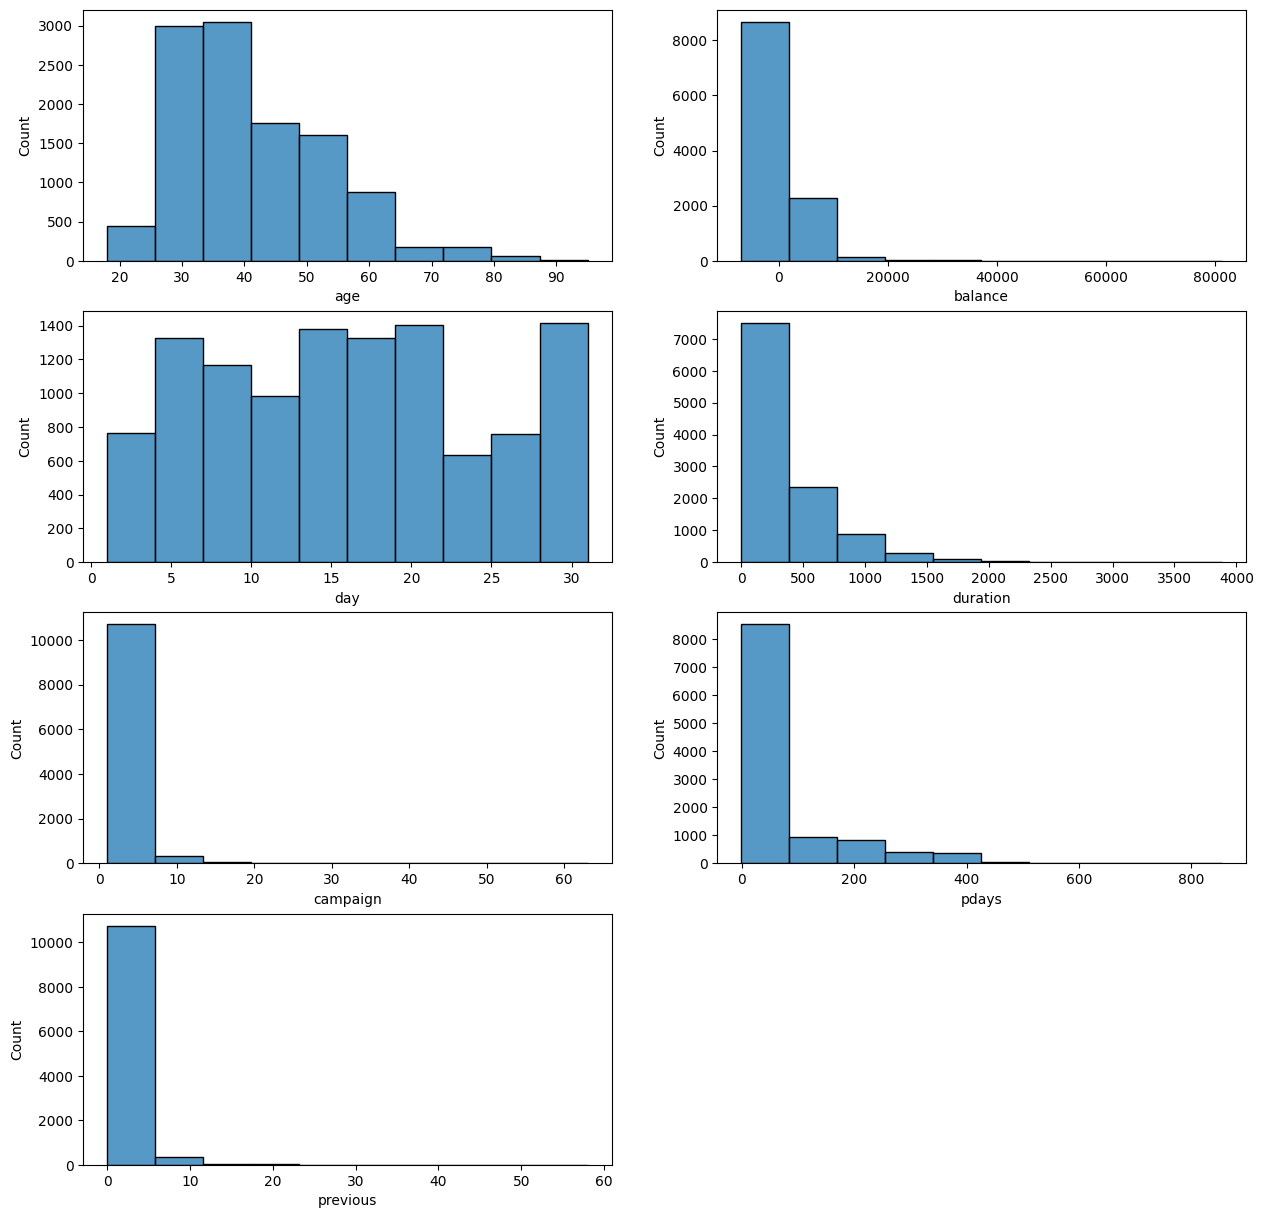

In [17]:
plt.figure(figsize=(15,15))
for i,col in enumerate(numerical.columns):
    plt.subplot(4,2,i+1)
    sns.histplot(numerical[col] ,bins=10  )

plt.show()

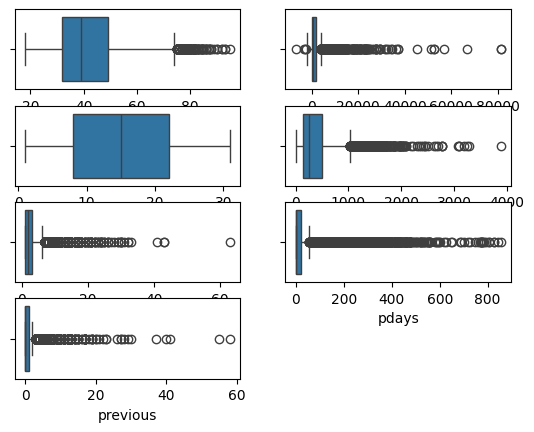

In [19]:
plt.Figure(figsize=(15,15))
for i ,col in enumerate(numerical.columns):
    plt.subplot(4,2,i+1)
    sns.boxplot(data[col],orient='h')

plt.show()

<Axes: >

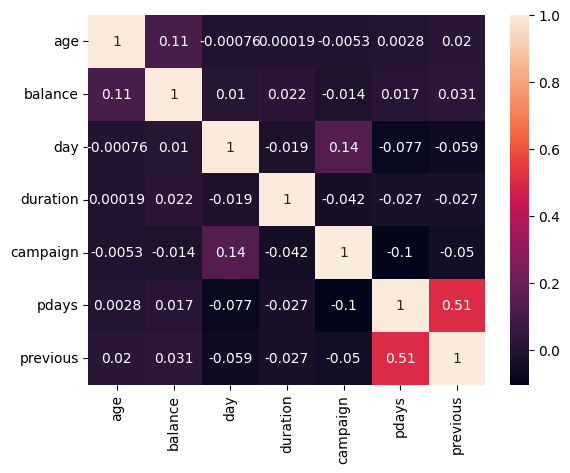

In [23]:
corr =numerical.corr()
plt.Figure(figsize=(20,15))
sns.heatmap(corr ,annot =True )


Text(0.5, 1.0, 'Age')

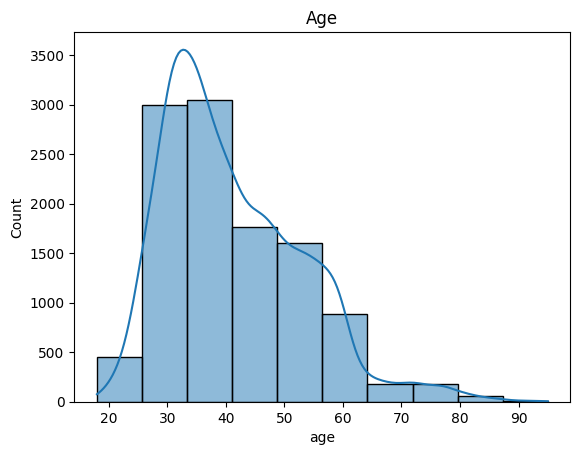

In [20]:
plt.Figure(figsize=(20,15))
sns.histplot(data['age'] ,bins= 10 ,kde =True)
plt.title('Age')

Text(0.5, 1.0, 'Balance Boxplot')

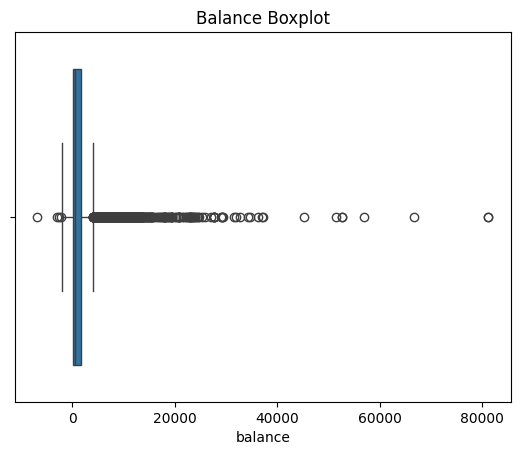

In [21]:
plt.Figure(figsize=(20,15))
sns.boxplot(data['balance'] , orient='h')
plt.title('Balance Boxplot')

Text(0.5, 1.0, 'Duration')

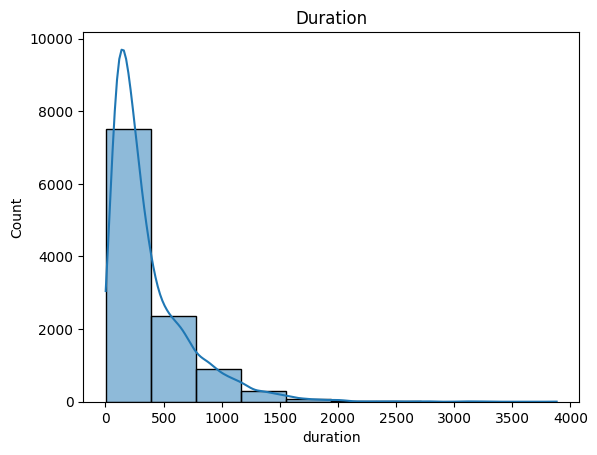

In [27]:
plt.Figure(figsize=(20,15))
sns.histplot(data['duration'] ,bins= 10 ,kde =True)
plt.title('Duration')

Text(0, 0.5, 'Count')

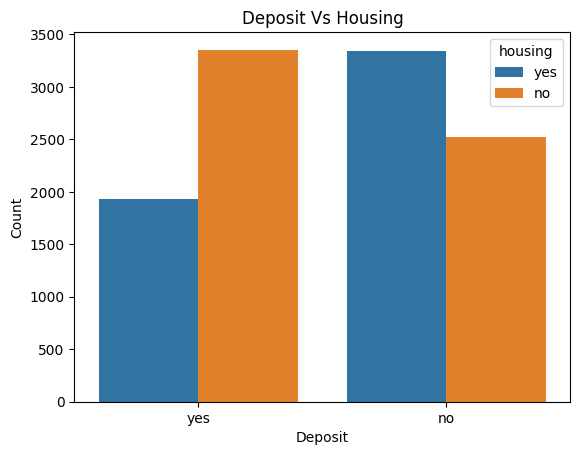

In [24]:
plt.Figure(figsize=(20,15))
sns.countplot(x= data['deposit'] ,hue = data['housing'])
plt.title('Deposit Vs Housing')
plt.xlabel('Deposit')
plt.ylabel('Count')


Text(0, 0.5, 'job')

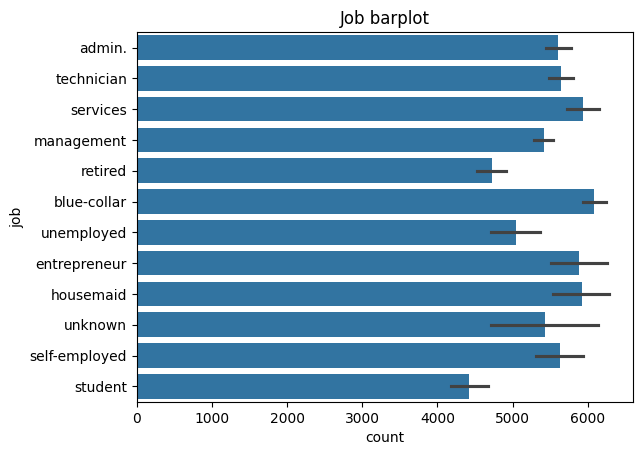

In [25]:
plt.Figure(figsize=(20,15))
sns.barplot(data['job'] )
plt.title('Job barplot')
plt.xlabel('count')
plt.ylabel('job')

Text(0, 0.5, 'deposit')

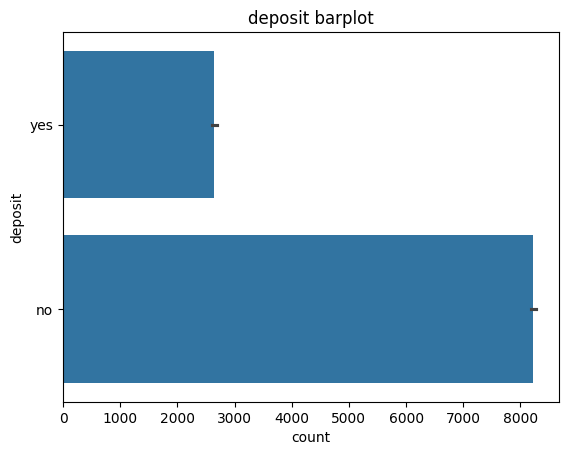

In [26]:
plt.Figure(figsize=(20,15))
sns.barplot(data['deposit'])
plt.title('deposit barplot')
plt.xlabel('count')
plt.ylabel('deposit')

Which preprocessing method was most effective for this dataset?
all of them are effective for different reason but may be the null check is the most effective because it clean the data from null values 

Which feature seems most related to deposit subscription?
duration is the most related because when the duration of the call increase that means the client is intrested

What problems could appear if preprocessing is skipped?
we will not understand the data and the feaure distribution of our data and if there are any null or dublicated values that may effect the model we can not know it 